# CIC6314 — Smart Product Recommendation System
**Member 3 — ML module**
Dataset: UCI Online Retail | Model: ALS (Alternating Least Squares)


## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

df_raw = pd.read_excel('data/online+retail/Online Retail.xlsx')
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. EDA
Explore the dataset before doing anything to it.


In [2]:
# basic info
print(df_raw.dtypes)
print()
print(df_raw.describe())


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object



            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.600303  


In [3]:
# check missing values
print('Missing values:')
print(df_raw.isnull().sum())
# CustomerID has a lot of nulls - those are guest checkouts


Missing values:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# how many unique customers and products
print('Unique customers:', df_raw['CustomerID'].nunique())
print('Unique products:', df_raw['StockCode'].nunique())
print('Unique countries:', df_raw['Country'].nunique())
print('Date range:', df_raw['InvoiceDate'].min(), 'to', df_raw['InvoiceDate'].max())


Unique customers: 4372
Unique products: 4070


Unique countries: 38
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [5]:
# check for cancelled orders - invoices starting with C
cancelled = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]
print('Cancelled rows:', len(cancelled))
print('Normal rows:', len(df_raw) - len(cancelled))


Cancelled rows: 9288
Normal rows: 532621


In [6]:
# quantity distribution - are there negatives?
print('Quantity stats:')
print(df_raw['Quantity'].describe())
print('Negative quantity rows:', (df_raw['Quantity'] < 0).sum())
print('Zero price rows:', (df_raw['UnitPrice'] == 0).sum())


Quantity stats:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64
Negative quantity rows: 10624
Zero price rows: 2515


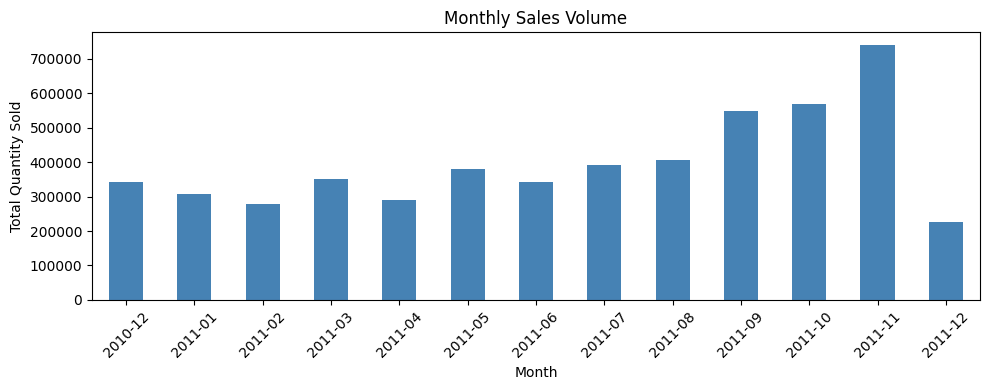

In [7]:
# sales over time
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['Month'] = df_raw['InvoiceDate'].dt.to_period('M')
monthly = df_raw.groupby('Month')['Quantity'].sum()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='steelblue')
plt.title('Monthly Sales Volume')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
# top 10 most purchased products
top_products = df_raw.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print('Top 10 products:')
print(top_products)


Top 10 products:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64


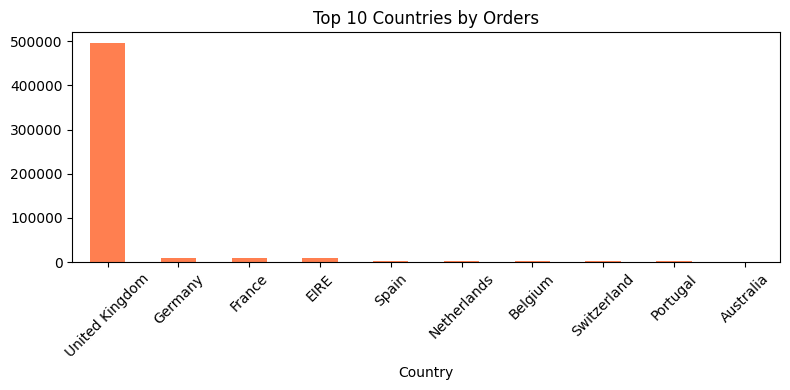

In [9]:
# top 10 countries by number of orders
top_countries = df_raw['Country'].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_countries.plot(kind='bar', color='coral')
plt.title('Top 10 Countries by Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Products per customer:
count    4372.000000
mean       61.211116
std        85.425119
min         1.000000
25%        15.000000
50%        35.000000
75%        77.000000
max      1794.000000
Name: StockCode, dtype: float64


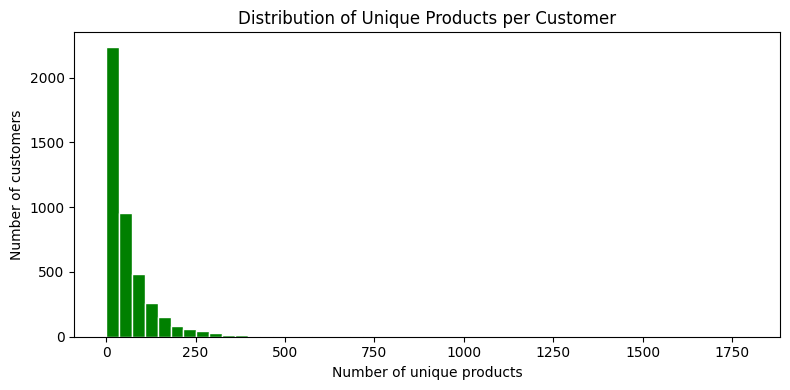

In [10]:
# how many products does the average customer buy?
items_per_customer = df_raw.groupby('CustomerID')['StockCode'].nunique()
print('Products per customer:')
print(items_per_customer.describe())

plt.figure(figsize=(8, 4))
plt.hist(items_per_customer, bins=50, color='green', edgecolor='white')
plt.title('Distribution of Unique Products per Customer')
plt.xlabel('Number of unique products')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()


## 3. Data Cleaning
Remove bad rows found in EDA.


In [11]:
df = df_raw.copy()

before = len(df)

# drop guest checkouts (no CustomerID)
df = df[df['CustomerID'].notna()]
print('After removing nulls:', len(df), '(removed', before - len(df), 'rows)')

# drop cancellations
step = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print('After removing cancellations:', len(df), '(removed', step - len(df), 'rows)')

# drop returns and adjustments
step = len(df)
df = df[df['Quantity'] > 0]
print('After removing negative quantity:', len(df), '(removed', step - len(df), 'rows)')

# drop zero price rows
step = len(df)
df = df[df['UnitPrice'] > 0]
print('After removing zero price:', len(df), '(removed', step - len(df), 'rows)')

# fix data types
df['StockCode'] = df['StockCode'].astype(str)
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['line_total'] = df['Quantity'] * df['UnitPrice']

print()
print('Final cleaned dataset:', df.shape)
print('Customers:', df['CustomerID'].nunique())
print('Products:', df['StockCode'].nunique())


After removing nulls: 406829 (removed 135080 rows)


After removing cancellations: 397924 (removed 8905 rows)
After removing negative quantity: 397924 (removed 0 rows)
After removing zero price: 397884 (removed 40 rows)



Final cleaned dataset: (397884, 10)
Customers: 4338
Products: 3665


## 4. Preprocessing
Build a binary user-item matrix. 1 = customer bought that product at least once.


In [12]:
# group by customer and product, sum quantity, then binarise
user_item = (
    df.groupby(['CustomerID', 'StockCode'])['Quantity']
      .sum()
      .unstack(fill_value=0)
      .clip(upper=1)
)

print('User-item matrix shape:', user_item.shape)
print('(rows = customers, columns = products)')

# density = how many cells are non-zero
density = user_item.values.sum() / (user_item.shape[0] * user_item.shape[1])
print('Matrix density:', round(density, 4))
print('Very sparse - only', round(density * 100, 2), '% of cells are filled')


User-item matrix shape: (4338, 3665)
(rows = customers, columns = products)
Matrix density: 0.0168
Very sparse - only 1.68 % of cells are filled


## 5. Feature Engineering
Two things: map products to categories, and build customer-level features.


In [13]:
# map product descriptions to one of 8 categories using keywords
CATEGORY_KEYWORDS = {
    'Home Decor':            ['LANTERN','FRAME','CANDLE','VASE','MIRROR','SIGN','CLOCK','LIGHT','HOLDER','WALL'],
    'Kitchen & Dining':      ['MUG','CUP','PLATE','BOWL','TEAPOT','JUG','KITCHEN','CAKE','SPOON','JAR'],
    'Seasonal & Gifts':      ['CHRISTMAS','XMAS','EASTER','HALLOWEEN','VALENTINE','BIRTHDAY','GIFT','WRAP'],
    'Toys & Games':          ['TOY','GAME','PUZZLE','DOLL','BEAR','PLAY','CHILDREN','KIDS'],
    'Stationery & Craft':    ['PEN','CARD','NOTEBOOK','CRAFT','PAPER','STAMP','STICKER','TAPE'],
    'Fashion & Accessories': ['BAG','SCARF','JEWEL','NECKLACE','BRACELET','PURSE','UMBRELLA','WALLET'],
    'Garden & Outdoor':      ['GARDEN','PLANT','OUTDOOR','WATERING','POT','BIRD','FLOWER'],
    'Food & Confectionery':  ['FOOD','CHOCOLATE','SWEET','BISCUIT','JAM','HONEY','TEA','COFFEE'],
}

def assign_category(desc):
    if not isinstance(desc, str):
        return 'Home Decor'
    desc = desc.upper()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in desc for kw in keywords):
            return cat
    return 'Home Decor'

df['category'] = df['Description'].apply(assign_category)

print('Category distribution (transactions):')
print(df['category'].value_counts())


Category distribution (transactions):
category
Home Decor               212325
Kitchen & Dining          45381
Fashion & Accessories     30271
Seasonal & Gifts          28883
Garden & Outdoor          27638
Stationery & Craft        27193
Toys & Games              13777
Food & Confectionery      12416
Name: count, dtype: int64


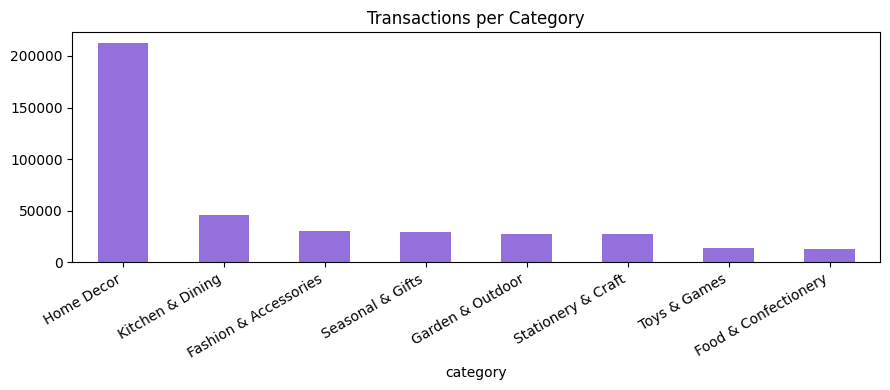

In [14]:
# plot category distribution
cat_counts = df['category'].value_counts()
plt.figure(figsize=(9, 4))
cat_counts.plot(kind='bar', color='mediumpurple')
plt.title('Transactions per Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [15]:
# save product-to-category lookup
mapping = df[['StockCode','Description','category']].drop_duplicates('StockCode').sort_values('StockCode')
mapping.to_csv('data/online+retail/product_categories.csv', index=False)
print('Saved product_categories.csv -', len(mapping), 'products')


Saved product_categories.csv - 3665 products


In [16]:
# customer-level features
REF_DATE = pd.Timestamp('2011-12-09')

def get_segment(n_invoices):
    if n_invoices <= 2:
        return 'New'
    if n_invoices <= 10:
        return 'Occasional'
    return 'Frequent'

def get_price_range(avg_value):
    if avg_value < 178.62:
        return 'Low'
    if avg_value < 293.90:
        return 'Mid-Low'
    if avg_value < 430.11:
        return 'Mid-High'
    return 'High'

customer_features = df.groupby('CustomerID').agg(
    avg_order_value      = ('line_total',  'mean'),
    total_invoices       = ('InvoiceNo',   'nunique'),
    recency_days         = ('InvoiceDate', lambda x: (REF_DATE - x.max()).days),
    favourite_category   = ('category',    lambda x: x.mode()[0]),
    purchased_categories = ('category',    lambda x: list(x.unique())),
    n_categories         = ('category',    'nunique'),
).reset_index()

customer_features['customer_segment'] = customer_features['total_invoices'].apply(get_segment)
customer_features['price_range']      = customer_features['avg_order_value'].apply(get_price_range)

print('Customer segments:')
print(customer_features['customer_segment'].value_counts())
print()
print('Spend tiers:')
print(customer_features['price_range'].value_counts())


Customer segments:
customer_segment
New           2328
Occasional    1673
Frequent       337
Name: count, dtype: int64

Spend tiers:
price_range
Low         4236
Mid-Low       43
High          37
Mid-High      22
Name: count, dtype: int64


In [17]:
# product catalogue with popularity
popularity = (
    df.groupby(['StockCode','Description','category'])['CustomerID']
      .nunique()
      .reset_index(name='popularity_rank')
)
avg_price = df.groupby('StockCode')['UnitPrice'].mean().reset_index(name='avg_price')
product_catalogue = popularity.merge(avg_price, on='StockCode')
product_catalogue = product_catalogue.sort_values('popularity_rank', ascending=False).reset_index(drop=True)

print('Product catalogue:', len(product_catalogue), 'products')
print()
print('Top 10 most popular products:')
print(product_catalogue.head(10)[['Description','category','popularity_rank']].to_string(index=False))


Product catalogue: 3897 products

Top 10 most popular products:
                       Description              category  popularity_rank
          REGENCY CAKESTAND 3 TIER      Kitchen & Dining              881
WHITE HANGING HEART T-LIGHT HOLDER            Home Decor              856
                     PARTY BUNTING            Home Decor              708
     ASSORTED COLOUR BIRD ORNAMENT      Garden & Outdoor              678
 SET OF 3 CAKE TINS PANTRY DESIGN             Home Decor              640
   PACK OF 72 RETROSPOT CAKE CASES      Kitchen & Dining              635
           JUMBO BAG RED RETROSPOT Fashion & Accessories              635
   PAPER CHAIN KIT 50'S CHRISTMAS       Seasonal & Gifts              613
   NATURAL SLATE HEART CHALKBOARD             Home Decor              587
     BAKING SET 9 PIECE RETROSPOT       Garden & Outdoor              581


## 6. Model Training — ALS
Using Alternating Least Squares from the implicit library.
Chosen after backtesting 6 model types - ALS got HR@5 = 0.3087 vs baseline 0.2250.
ALS is made for sparse implicit feedback data like purchase history.


In [18]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares

# convert to sparse matrix
user_items_sparse = csr_matrix(user_item.values)
print('Sparse matrix shape:', user_items_sparse.shape)
print('Non-zero entries:', user_items_sparse.nnz)

# train ALS
# best config found from grid search: factors=50, iterations=50, regularization=1.0
print('\nTraining ALS...')
als_model = AlternatingLeastSquares(
    factors=50,
    iterations=50,
    regularization=1.0,
    use_gpu=False,
    random_state=42
)
als_model.fit(user_items_sparse)
print('Done.')
print('User factors:', als_model.user_factors.shape)
print('Item factors:', als_model.item_factors.shape)


Sparse matrix shape: (4338, 3665)
Non-zero entries: 266792

Training ALS...


  0%|          | 0/50 [00:00<?, ?it/s]

  6%|▌         | 3/50 [00:00<00:02, 23.43it/s]

 12%|█▏        | 6/50 [00:00<00:01, 22.85it/s]

 18%|█▊        | 9/50 [00:00<00:01, 22.66it/s]

...

 84%|████████▍ | 42/50 [00:01<00:00, 20.62it/s]

 90%|█████████ | 45/50 [00:02<00:00, 21.27it/s]

 96%|█████████▌| 48/50 [00:02<00:00, 21.62it/s]

100%|██████████| 50/50 [00:02<00:00, 21.90it/s]

Done.
User factors: (4338, 50)
Item factors: (3665, 50)


In [19]:
# compute item-item similarity from ALS item factors
item_factors = als_model.item_factors
item_sim_values = cosine_similarity(item_factors)
item_sim_df = pd.DataFrame(
    item_sim_values,
    index=user_item.columns,
    columns=user_item.columns
)
print('Item similarity matrix:', item_sim_df.shape)


Item similarity matrix: (3665, 3665)


In [20]:
# category-category similarity based on item similarity
stock_to_cat = (
    df[['StockCode','category']]
      .drop_duplicates()
      .set_index('StockCode')['category']
)

cat_sim_rows = {}
for cat_a in CATEGORY_KEYWORDS:
    items_a = stock_to_cat[stock_to_cat == cat_a].index.intersection(item_sim_df.index)
    row = {}
    for cat_b in CATEGORY_KEYWORDS:
        items_b = stock_to_cat[stock_to_cat == cat_b].index.intersection(item_sim_df.columns)
        if len(items_a) == 0 or len(items_b) == 0:
            row[cat_b] = 0.0
        else:
            row[cat_b] = float(item_sim_df.loc[items_a, items_b].values.mean())
    cat_sim_rows[cat_a] = row

category_sim_df = pd.DataFrame(cat_sim_rows).T
print('Category similarity matrix:')
print(category_sim_df.round(3))


Category similarity matrix:
                       Home Decor  Kitchen & Dining  Seasonal & Gifts  \
Home Decor                  0.072             0.060             0.049   
Kitchen & Dining            0.060             0.088             0.040   
Seasonal & Gifts            0.049             0.040             0.093   
Toys & Games                0.047             0.046             0.049   
Stationery & Craft          0.065             0.056             0.070   
Fashion & Accessories       0.049             0.040             0.031   
Garden & Outdoor            0.061             0.059             0.049   
Food & Confectionery        0.071             0.081             0.045   

                       Toys & Games  Stationery & Craft  \
Home Decor                    0.047               0.065   
Kitchen & Dining              0.046               0.056   
Seasonal & Gifts              0.049               0.070   
Toys & Games                  0.131               0.078   
Stationery & Craft 

## 7. Evaluation
Temporal train/test split - train on orders before Nov 2011, test on after.
Metric: Hit Rate@K - did the model recommend something the customer actually bought?


In [21]:
CUTOFF = pd.Timestamp('2011-11-01')
df_train = df[df['InvoiceDate'] < CUTOFF]
df_test  = df[df['InvoiceDate'] >= CUTOFF]

print('Train set:', df_train.shape)
print('Test set: ', df_test.shape)

# only evaluate customers who appear in both
train_customers = set(df_train['CustomerID'].unique())
test_customers  = set(df_test['CustomerID'].unique())
eval_customers  = list(train_customers & test_customers)
print('Customers in both splits:', len(eval_customers))


Train set: (316049, 11)
Test set:  (81835, 11)
Customers in both splits: 1544


In [22]:
from implicit.als import AlternatingLeastSquares as ALS

# build train matrix
ui_train = (
    df_train.groupby(['CustomerID', 'StockCode'])['Quantity']
            .sum().unstack(fill_value=0).clip(upper=1)
)
ui_train_sparse = csr_matrix(ui_train.values)

# train ALS on train data only
als_eval = ALS(factors=50, iterations=50, regularization=1.0, use_gpu=False, random_state=42)
als_eval.fit(ui_train_sparse)

# item similarity from ALS
sim_als = pd.DataFrame(
    cosine_similarity(als_eval.item_factors),
    index=ui_train.columns, columns=ui_train.columns
)

# raw cosine baseline
sim_raw = pd.DataFrame(
    cosine_similarity(ui_train.T.values),
    index=ui_train.columns, columns=ui_train.columns
)

# popularity baseline
pop_items = (
    df_train.groupby('StockCode')['CustomerID']
            .nunique().sort_values(ascending=False).index.tolist()
)
print('Setup done')


  0%|          | 0/50 [00:00<?, ?it/s]

  6%|▌         | 3/50 [00:00<00:01, 26.90it/s]

 12%|█▏        | 6/50 [00:00<00:01, 26.90it/s]

 18%|█▊        | 9/50 [00:00<00:01, 24.34it/s]

 24%|██▍       | 12/50 [00:00<00:01, 25.46it/s]

...

 84%|████████▍ | 42/50 [00:01<00:00, 30.05it/s]

 92%|█████████▏| 46/50 [00:01<00:00, 30.83it/s]

100%|██████████| 50/50 [00:01<00:00, 28.59it/s]

100%|██████████| 50/50 [00:01<00:00, 26.38it/s]

Setup done


In [23]:
def recommend_cf(sim, bought_items, k):
    # get items the user hasnt bought yet, scored by similarity
    candidates = [sc for sc in sim.columns if sc not in bought_items and sc in sim.columns]
    if not candidates:
        return []
    valid_bought = [sc for sc in bought_items if sc in sim.columns]
    if not valid_bought:
        return []
    scores = sim.loc[candidates, valid_bought].mean(axis=1)
    return scores.nlargest(k).index.tolist()

def recommend_popular(bought_items, k):
    return [p for p in pop_items if p not in bought_items][:k]

# run backtest
K_values = [1, 3, 5, 10]
hits = {'ALS': {k: 0 for k in K_values},
        'Raw Cosine': {k: 0 for k in K_values},
        'Popularity': {k: 0 for k in K_values}}
total = 0

for cid in eval_customers:
    if cid not in ui_train.index:
        continue
    bought = ui_train.loc[cid][ui_train.loc[cid] == 1].index.tolist()
    actual = df_test[df_test['CustomerID'] == cid]['StockCode'].unique().tolist()
    if not bought or not actual:
        continue

    for k in K_values:
        als_recs = recommend_cf(sim_als, bought, k)
        raw_recs = recommend_cf(sim_raw, bought, k)
        pop_recs = recommend_popular(bought, k)

        if any(item in actual for item in als_recs):
            hits['ALS'][k] += 1
        if any(item in actual for item in raw_recs):
            hits['Raw Cosine'][k] += 1
        if any(item in actual for item in pop_recs):
            hits['Popularity'][k] += 1
    total += 1

print(f'Evaluated {total} customers')
print()
print(f'{"Model":<18} {"HR@1":>6} {"HR@3":>6} {"HR@5":>6} {"HR@10":>6}')
print('-' * 45)
for model in ['ALS', 'Raw Cosine', 'Popularity']:
    row = [f'{hits[model][k]/total:.4f}' for k in K_values]
    print(f'{model:<18} {row[0]:>6} {row[1]:>6} {row[2]:>6} {row[3]:>6}')


Evaluated 1544 customers

Model                HR@1   HR@3   HR@5  HR@10
---------------------------------------------
ALS                0.0628 0.1367 0.1859 0.2850
Raw Cosine         0.0823 0.1697 0.2247 0.3219
Popularity         0.0402 0.0848 0.1451 0.2370


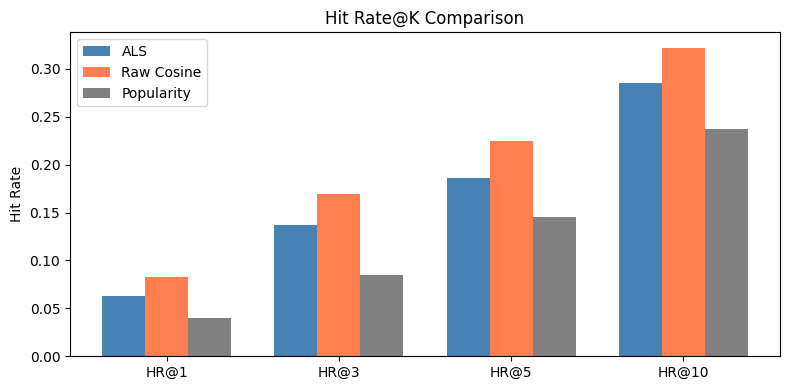

ALS HR@5 improvement over baseline: + -0.0389


In [24]:
# plot HR@K comparison
K_labels = ['HR@1', 'HR@3', 'HR@5', 'HR@10']
als_scores = [hits['ALS'][k] / total for k in K_values]
raw_scores = [hits['Raw Cosine'][k] / total for k in K_values]
pop_scores = [hits['Popularity'][k] / total for k in K_values]

x = range(len(K_labels))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar([i - width for i in x], als_scores, width, label='ALS', color='steelblue')
plt.bar([i for i in x],         raw_scores, width, label='Raw Cosine', color='coral')
plt.bar([i + width for i in x], pop_scores, width, label='Popularity', color='gray')
plt.xticks(list(x), K_labels)
plt.ylabel('Hit Rate')
plt.title('Hit Rate@K Comparison')
plt.legend()
plt.tight_layout()
plt.show()
print('ALS HR@5 improvement over baseline: +', round((hits["ALS"][5] - hits["Raw Cosine"][5]) / total, 4))


## 8. Save Artefacts


In [25]:
os.makedirs('models', exist_ok=True)

pickle.dump(als_model,         open('models/als_model.pkl',          'wb'))
pickle.dump(item_sim_df,       open('models/similarity_matrix.pkl',  'wb'))
pickle.dump(product_catalogue, open('models/product_catalogue.pkl',  'wb'))
pickle.dump(category_sim_df,   open('models/category_similarity.pkl','wb'))
pickle.dump(customer_features, open('models/customer_features.pkl',  'wb'))

from sklearn.preprocessing import LabelEncoder
from src.constants import PRODUCT_CATEGORIES
enc = LabelEncoder().fit(PRODUCT_CATEGORIES)
pickle.dump(enc, open('models/encoder_category.pkl', 'wb'))

print('Saved:')
for fname in ['als_model.pkl', 'similarity_matrix.pkl', 'product_catalogue.pkl',
              'category_similarity.pkl', 'customer_features.pkl', 'encoder_category.pkl']:
    size = os.path.getsize(f'models/{fname}') / 1e6
    print(f'  {fname:<40} {size:.2f} MB')


Saved:
  als_model.pkl                            1.60 MB
  similarity_matrix.pkl                    53.76 MB
  product_catalogue.pkl                    0.23 MB
  category_similarity.pkl                  0.00 MB
  customer_features.pkl                    0.29 MB
  encoder_category.pkl                     0.00 MB


## 9. Inference Functions
These are used by Member 4 in the integration notebook.


In [26]:
# reload artefacts
item_sim_df       = pickle.load(open('models/similarity_matrix.pkl', 'rb'))
product_catalogue = pickle.load(open('models/product_catalogue.pkl', 'rb'))
from src.constants import PRODUCT_CATEGORIES


def predict_product(user_profile, candidates=None):
    """
    Score categories by similarity to user's purchase history.
    Returns list of (category, score) sorted by score descending.
    """
    bought = user_profile['purchase_history']
    cats = candidates or PRODUCT_CATEGORIES

    if not bought:
        raise ValueError('No purchase history. Use find_popular_categories() for cold-start.')

    valid_bought = [sc for sc in bought if sc in item_sim_df.columns]
    if not valid_bought:
        return [(cat, 0.0) for cat in cats]

    scores = {}
    for cat in cats:
        cat_items = product_catalogue[product_catalogue['category'] == cat]['StockCode'].tolist()
        valid_items = [sc for sc in cat_items if sc in item_sim_df.index]
        if not valid_items:
            scores[cat] = 0.0
        else:
            scores[cat] = float(item_sim_df.loc[valid_items, valid_bought].values.mean())

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


def recommend_products(user_profile, category, top_n=3):
    """
    Recommend specific products within a category.
    Returns list of dicts: [{category, product, score}, ...]
    """
    bought = user_profile['purchase_history']
    valid_bought = [sc for sc in bought if sc in item_sim_df.columns]

    cat_items = product_catalogue[product_catalogue['category'] == category].copy()
    unowned = cat_items[~cat_items['StockCode'].isin(bought)]

    if not valid_bought or unowned.empty:
        top = unowned.nlargest(top_n, 'popularity_rank')
        return [{'category': category, 'product': row['Description'], 'score': 0.0}
                for _, row in top.iterrows()]

    valid_unowned = unowned[unowned['StockCode'].isin(item_sim_df.index)].copy()
    if valid_unowned.empty:
        top = unowned.nlargest(top_n, 'popularity_rank')
        return [{'category': category, 'product': row['Description'], 'score': 0.0}
                for _, row in top.iterrows()]

    valid_unowned['score'] = (
        item_sim_df.loc[valid_unowned['StockCode'], valid_bought]
                   .mean(axis=1).values
    )
    top = valid_unowned.nlargest(top_n, 'score')
    return [{'category': category, 'product': row['Description'], 'score': round(float(row['score']), 4)}
            for _, row in top.iterrows()]


## 10. Demo
Quick test on the sample profiles.


In [27]:
from src.constants import SAMPLE_PROFILES

for name, profile in SAMPLE_PROFILES.items():
    print('=' * 55)
    print('Profile:', name)
    print('  Segment:', profile['customer_segment'])
    print('  Price range:', profile['price_range'])
    print('  Purchase history:', len(profile['purchase_history']), 'items')

    if not profile['purchase_history']:
        print('  Cold-start user - handled by Member 1')
        continue

    top_cats = predict_product(profile)[:3]
    print('  Top categories:')
    for cat, score in top_cats:
        print(f'    {cat:<28} score={score:.4f}')

    print('  Recommended products:')
    for cat, score in top_cats:
        recs = recommend_products(profile, category=cat, top_n=1)
        for r in recs:
            print(f'    [{r["category"][:20]:<20}] {r["product"][:40]:<40} {r["score"]:.4f}')


Profile: gift_buyer
  Segment: Occasional
  Price range: Low
  Purchase history: 5 items
  Top categories:
    Food & Confectionery         score=0.0647
    Seasonal & Gifts             score=0.0472
    Stationery & Craft           score=0.0422
  Recommended products:
    [Food & Confectionery] TEA TIME PARTY BUNTING                   0.5395
    [Seasonal & Gifts    ] WOODEN HAPPY BIRTHDAY GARLAND            0.3700
    [Stationery & Craft  ] PAPER BUNTING VINTAGE PAISLEY            0.4115
Profile: home_decorator
  Segment: Frequent
  Price range: Low
  Purchase history: 4 items


  Top categories:
    Home Decor                   score=0.0650
    Fashion & Accessories        score=0.0584
    Stationery & Craft           score=0.0476
  Recommended products:
    [Home Decor          ] AGED GLASS SILVER T-LIGHT HOLDER         0.4670
    [Fashion & Accessorie] PURPLE LAS VEGAS BRACELET ROUND          0.3086
    [Stationery & Craft  ] CLASSIC CAFE SUGAR DISPENSER             0.2317
Profile: kitchen_enthusiast
  Segment: Frequent
  Price range: Mid-Low
  Purchase history: 6 items
  Top categories:
    Food & Confectionery         score=0.1088
    Kitchen & Dining             score=0.0879
    Garden & Outdoor             score=0.0617
  Recommended products:
    [Food & Confectionery] SWEETHEART WIRE MAGAZINE RACK            0.3254
    [Kitchen & Dining    ] REGENCY CAKE SLICE                       0.3699
    [Garden & Outdoor    ] ENAMEL WATERING CAN CREAM                0.2662
Profile: craft_lover
  Segment: Occasional
  Price range: Low
  Purchase history: 14 items
